## Focus on selected cardiac TF gene regulatory networks

In [1]:
!date +%F

2025-02-27


In [16]:
#!/usr/bin/env python3
import os
import re
import sys
print(sys.executable)
print(sys.path)
print(sys.version)

import random
import pickle
from itertools import combinations
import matplotlib
import glob
import math
%matplotlib inline
import matplotlib.gridspec as gridspec
import networkx as nx
import gseapy as gp
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

from venn import venn
from matplotlib.pyplot import subplots
from venn import pseudovenn

plt.rcParams.update({'pdf.fonttype':42}) 

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse

from tqdm import tqdm
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', scipy.__version__)
print('matplotlib', matplotlib.__version__)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/bin/python
['/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python312.zip', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/lib-dynload', '', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages']
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
numpy 1.26.4
pandas 2.2.1
scipy 1.12.0
matplotlib 3.8.3


In [3]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [4]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

### confirm the regulation with TF motif
* use bedtool intersect on terminal

In [5]:
TF_motif_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/TF_motif/All_DE_motif/All_DEgenes_TFmotif.txt'

In [6]:
TF_motif_unfilter = pd.read_csv(TF_motif_file, sep='\t', names=['rechr', 'restart', 'reend', 'gene', 'chr', 'start', 'end', 'motif', 'pos', 'strand', 'TF', 'overlap'])

In [7]:
#make sure TF names are comply with gene names
TF_motif_unfilter['TF'] = TF_motif_unfilter['TF'].str.upper()

In [8]:
TF_motif = TF_motif_unfilter[TF_motif_unfilter['overlap'] > 5]

In [9]:
TF_motif.shape

(22325014, 12)

In [10]:
TF_motif[TF_motif['TF'] == 'HAND1']

,rechr,restart,reend,gene,chr,start,end,motif,pos,strand,TF,overlap
6,chr10,100009709,100010209,DNMBP,chr10,100009706,100009715,MA2123.1,355,+,HAND1,6
512,chr10,100009709,100010209,DNMBP,chr10,100009816,100009825,MA2123.1,305,-,HAND1,9
783,chr10,100009709,100010209,DNMBP,chr10,100009886,100009895,MA2123.1,298,+,HAND1,9
2551,chr10,100346604,100347104,SCD,chr10,100346659,100346668,MA2123.1,366,+,HAND1,9
3373,chr10,100346604,100347104,SCD,chr10,100346841,100346850,MA2123.1,308,+,HAND1,9
...,...,...,...,...,...,...,...,...,...,...,...,...
23136537,chrX,93673270,93673770,FAM133A,chrX,93673758,93673767,MA2123.1,316,+,HAND1,9
23139654,chrX,9786235,9786735,SHROOM2,chrX,9786252,9786261,MA2123.1,318,-,HAND1,9
23139676,chrX,9786235,9786735,SHROOM2,chrX,9786260,9786269,MA2123.1,302,-,HAND1,9
23140096,chrX,9786235,9786735,SHROOM2,chrX,9786348,9786357,MA2123.1,313,+,HAND1,9


### Load CHD genes

In [11]:
CHD_genes_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/OpenTarget/CHD_Yang/chdgene_table.csv', sep=',') 

In [12]:
CHD_genes_df.head(5)

,Gene,CHD classification,Extra cardiac phenotype,Inheritance mode,Ranking,Supporting References
0,ABL1,"ASD,VSD",Yes,"AD,DN",5,2
1,ACTC1,"ASD,VSD",Yes,AD,5,3
2,ACVR1,"ASD,AVSD and variants,Malformation of outflow ...",No,"AD,AR",5,2
3,ACVR2B,"ASD with minor abnormalities,VSD with minor ab...",Yes,AD,5,2
4,ADAMTS10,"VSD,Obstructive lesions",Yes,AR,5,2


In [13]:
CHD_TF = list(set(CHD_genes_df['Gene']).intersection(set(TF_region_df['TF'])))

In [14]:
len(CHD_TF)

50

### Load GRN

In [17]:
G = pickle.load(open('GRN_base.pickle', 'rb'))

In [18]:
TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]

In [19]:
G.degree("TBX5")

38

In [20]:
main_tf = [node for node in G.nodes if G.degree(node)>30]

In [21]:
combis = combinations(main_tf,2)
res = []
for tf1,tf2 in combis:
    tf1_dsg = list(G.successors(tf1))
    tf2_dsg = list(G.successors(tf2))
    shared = list(set(tf1_dsg) & set(tf2_dsg))
    res.append([tf1,tf2,len(shared)])

In [22]:
count_overlap_df = pd.DataFrame(res,columns=["TF1","TF2","overlap"])
count_overlap_df = count_overlap_df.sort_values("overlap",ascending=False)

In [23]:
count_overlap_df.head(20)

,TF1,TF2,overlap
1523,RCOR2,SOX11,498
13792,ISL1,TBX20,304
1552,RCOR2,TBX20,294
12382,SOX11,SOX4,275
12392,SOX11,TBX20,270
1539,RCOR2,ISL1,268
12379,SOX11,ISL1,243
1542,RCOR2,SOX4,206
6499,HOXB4,ISL1,181
1531,RCOR2,TADA2B,165


Target: ISL1, TBX20, SOX11, NKX2-5

### Load pySpade table

In [24]:
global_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/Manhattan_plots/filtered_df.csv')

In [25]:
basic_cutoff_list = [n for n, d in G.degree() if d > 1]
large_node_list = [n for n, d in G.degree() if d > 10] #get nodes for key TFs

In [26]:
print(len(basic_cutoff_list))
print(len(large_node_list))

5234
808


In [27]:
node_degree = np.array([float(G.degree(v)) for v in G if not v.startswith('chr')])
large_node_size = np.array([d for n, d in G.degree() if d > 10]) 
node_degree = np.clip(node_degree, 3, 20) #set the limit for plotting

In [28]:
print(len(large_node_size))
print(len(node_degree))

808
8438


In [29]:
nx.is_directed(G)

True

In [30]:
query_TF = ['ISL1', 'TBX20', 'SOX11','NKX2-5']
query_regions_list = ['chr5:51383449-51383518', 'chr7:35253814-35254121','chr2:5692396-5692511','chr5:173234977-173235210']

In [31]:
all_node = []
for tf in query_TF:
    all_node.append([tf])
    all_node.append(list(G.successors(tf)))
    
all_node = np.unique(np.concatenate(all_node))

In [32]:
G_sub = G.subgraph(all_node)
print(len(G_sub.nodes))
print(len(G_sub.edges))

2421
6004


#### Visualize with venn diagram

In [33]:
dataset_dict = {}
for tf in query_TF:
    dataset_dict[tf] = {node for node in G_sub.successors(tf)}

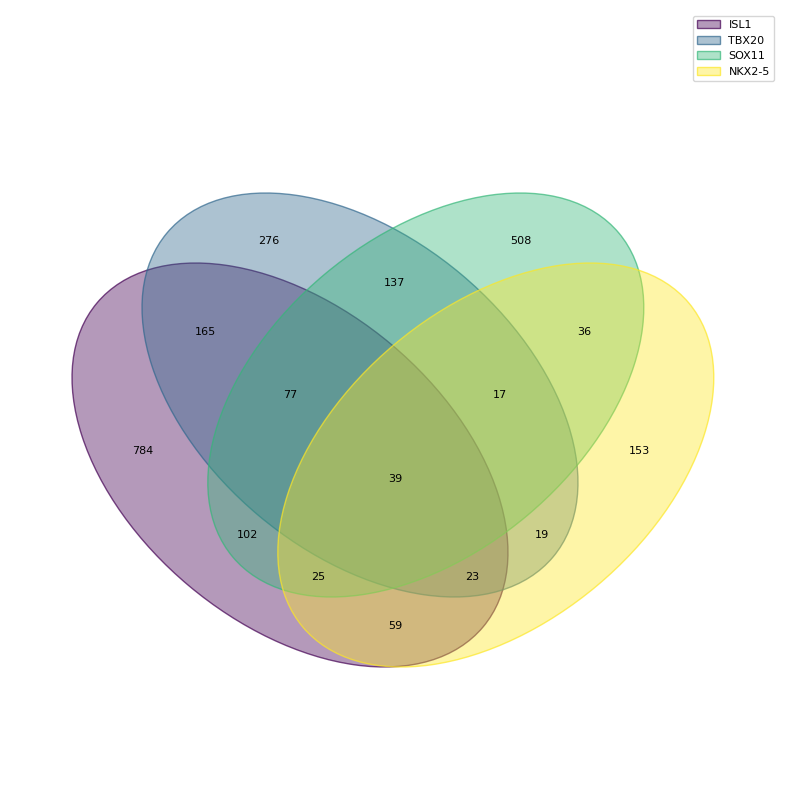

In [34]:
fig, ax = plt.subplots(figsize= (10,10))
venn(dataset_dict, cmap='viridis', fontsize=8, legend_loc="upper right", ax=ax)
plt.savefig("./Plot/4gene_overlap.pdf")

In [35]:
target_set = dataset_dict[query_TF[0]]
for tf in query_TF:
    target_set = dataset_dict[tf] & target_set

In [36]:
target_set

{'ACTN2',
 'ADD3',
 'BMP5',
 'CACNA1C',
 'CACNA1D',
 'CACNB2',
 'CCDC80',
 'CKM',
 'COL2A1',
 'CYB5A',
 'EDIL3',
 'ERBB4',
 'FTL',
 'FZD7',
 'HAPLN1',
 'HSPB7',
 'KCNQ5',
 'LAMA4',
 'LDB3',
 'LMO2',
 'MYL3',
 'MYL4',
 'MYO18B',
 'MYOCD',
 'MYOM1',
 'NEBL',
 'NREP',
 'PALLD',
 'PALM2-AKAP2',
 'PDE3A',
 'RYR2',
 'SLC3A2',
 'TCAP',
 'TMEM163',
 'TNNC1',
 'TNNI1',
 'TNNI3',
 'TNNT2',
 'TRIM55'}

In [49]:
test_chd_gene = [list(dataset_dict[tf] & set(CHD_genes_df['Gene'])) for tf in query_TF]
test_chd_gene = np.unique(np.concatenate(test_chd_gene))

regulated_pattern_dict = {}

for gene in test_chd_gene:
    pattern_str = ""
    for tf in query_TF:
        if gene in dataset_dict[tf]:
            pattern_str = pattern_str+tf+"_"
    if pattern_str in regulated_pattern_dict.keys():
        regulated_pattern_dict[pattern_str].append(gene)
    else:
        regulated_pattern_dict[pattern_str] = [gene]

In [50]:
regulated_pattern_dict

{'TBX20_SOX11_NKX2-5_': ['ACTC1', 'GPC3'],
 'SOX11_': ['B3GAT3', 'BMPR2', 'NKX2-5', 'PITX2', 'TBX20'],
 'NKX2-5_': ['CITED2', 'HAND1', 'JAG1', 'RBFOX2', 'TAB2'],
 'TBX20_SOX11_': ['FBN1', 'SMAD3', 'TBX5'],
 'ISL1_TBX20_': ['FOXC1', 'GATA5', 'MYBPC3', 'ZEB2'],
 'TBX20_': ['FOXC2', 'GLI3', 'HAND2', 'MEIS2', 'RERE'],
 'ISL1_SOX11_': ['FOXP1', 'GJA1'],
 'ISL1_NKX2-5_': ['GATA6', 'NKX2-6'],
 'ISL1_': ['HNRNPK',
  'HRAS',
  'NOTCH2',
  'PBX1',
  'RAB23',
  'SF3B4',
  'SMARCB1',
  'TRAF7'],
 'ISL1_TBX20_NKX2-5_': ['KDR', 'MYH7'],
 'ISL1_TBX20_SOX11_': ['MYH6', 'PRKD1'],
 'SOX11_NKX2-5_': ['SMAD2']}

In [44]:
test_chd_gene

[{'FOXC1',
  'FOXP1',
  'GATA5',
  'GATA6',
  'GJA1',
  'HNRNPK',
  'HRAS',
  'KDR',
  'MYBPC3',
  'MYH6',
  'MYH7',
  'NKX2-6',
  'NOTCH2',
  'PBX1',
  'PRKD1',
  'RAB23',
  'SF3B4',
  'SMARCB1',
  'TRAF7',
  'ZEB2'},
 {'ACTC1',
  'FBN1',
  'FOXC1',
  'FOXC2',
  'GATA5',
  'GLI3',
  'GPC3',
  'HAND2',
  'KDR',
  'MEIS2',
  'MYBPC3',
  'MYH6',
  'MYH7',
  'PRKD1',
  'RERE',
  'SMAD3',
  'TBX5',
  'ZEB2'},
 {'ACTC1',
  'B3GAT3',
  'BMPR2',
  'FBN1',
  'FOXP1',
  'GJA1',
  'GPC3',
  'MYH6',
  'NKX2-5',
  'PITX2',
  'PRKD1',
  'SMAD2',
  'SMAD3',
  'TBX20',
  'TBX5'},
 {'ACTC1',
  'CITED2',
  'GATA6',
  'GPC3',
  'HAND1',
  'JAG1',
  'KDR',
  'MYH7',
  'NKX2-6',
  'RBFOX2',
  'SMAD2',
  'TAB2'}]

In [ ]:
set(CHD_genes_df['Gene'])

In [ ]:
target_gene = "MYH7"
for tf in query_TF:
    print(tf,target_gene in dataset_dict[tf])